# Learning Curves

Notebook version of the learning-curve analyses you flagged: the training-level colored learning curves with one colorbar, plus the time-in-level summaries. Dataset and view selection follow the same pattern as the recent comparison notebooks.

## 1. Setup

In [68]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Datasets

`DATASET_SELECTIONS` is the safest option when mixing lines/cohorts. Set it to `None` to use all combinations of `LINES` and `COHORTS`. Use `ANIMAL_SELECTION` for a one-animal review.

In [69]:
LINES = ["CNTNAP2"]
COHORTS = ["cohort4"]

# Explicit selections can mix lines/cohorts, e.g.:
# DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("CNTNAP2", "cohort4"), ("SHANK3", "cohort1"), ("SHANK3", "cohort2")]

# Example: "ASD0033" for a single animal, or None for group comparisons.
ANIMAL_SELECTION = None

## 3. Choose Comparison

Common presets:

- Compare genotypes within selected datasets: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Keep cohorts/datasets separate within genotype: `COMPARISON = "genotypes"`, `SPLIT_BY = "dataset"`
- Compare the same genotype across datasets: `COMPARISON = "datasets"`, `GENOTYPES = ["hom"]`
- Compare experimentors within selected datasets: `COMPARISON = "experimentor"`
- One view per animal: `COMPARISON = "animals"`
- Fully custom: `COMPARISON = "custom"` and edit `CUSTOM_SPECS`.

In [70]:
COMPARISON = "experimenter"  # "genotypes", "datasets", "lines", "cohorts", "experimentor", "animals", or "custom"
SPLIT_BY = "none"         # for COMPARISON="genotypes": "none", "dataset", "line", or "cohort"
GENOTYPES = ["wt", "het", "hom"]

# Toggle experimenters at the data/view-building step. Use None for all, or e.g. ["HY", "MV"].
EXPERIMENTER_SELECTION = ["HY", "MV"]

CUSTOM_SPECS = [
    # {"name": "CNTNAP2 hom all cohorts", "line": "CNTNAP2", "genotype": "hom"},
]

## 4. Load Data And Build Views

Rerun this if you change dataset selection, comparison mode, genotype selection, animal selection, experimenter selection, or custom specs.

In [71]:
from GroupComparison.config import ViewSpec
from Pipeline.group_comparison import build_group_views, load_groupcomparison_data, summarize_views
from Pipeline.learning_curves import build_view_colors, build_view_labels

data = load_groupcomparison_data(
    lines=LINES,
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_plot = data["df_plot"]

if ANIMAL_SELECTION is not None:
    animal_id = str(ANIMAL_SELECTION).strip()
    df_plot = df_plot[df_plot["animal"].astype(str).str.strip() == animal_id].copy()
    if df_plot.empty:
        raise ValueError(f"No rows found for ANIMAL_SELECTION={animal_id!r} after dataset filters.")

if EXPERIMENTER_SELECTION is not None:
    selected_experimenters = {str(exp).strip() for exp in EXPERIMENTER_SELECTION}
    df_plot = df_plot[df_plot["experimenter"].astype(str).str.strip().isin(selected_experimenters)].copy()
    if df_plot.empty:
        raise ValueError(f"No rows found for EXPERIMENTER_SELECTION={sorted(selected_experimenters)!r} after dataset filters.")

if COMPARISON == "animals":
    animals = sorted(df_plot["animal"].dropna().astype(str).str.strip().unique())
    views = [
        ViewSpec(animal, lambda d, _animal=animal: d[d["animal"].astype(str).str.strip() == _animal].copy())
        for animal in animals
    ]
elif COMPARISON == "custom" and CUSTOM_SPECS:
    views = build_group_views(
        df_plot,
        comparison="custom",
        custom_specs=CUSTOM_SPECS,
    )
else:
    views = build_group_views(
        df_plot,
        comparison=COMPARISON,
        split_by=SPLIT_BY,
        genotypes=GENOTYPES,
    )

view_labels = build_view_labels(views)
view_colors = build_view_colors(df_plot, views)

EXPERIMENTER_COLOR_OVERRIDES = {
    "HY": "#DBCF6B",  # dry olive / puke-y green
    "MV": "#C7C7C7",  # light grey
}
for view in views:
    experimenter = str(view.name).split(" ", 1)[0]
    if experimenter in EXPERIMENTER_COLOR_OVERRIDES:
        view_colors[view.name] = EXPERIMENTER_COLOR_OVERRIDES[experimenter]

print("Loaded datasets:", data["selections"])
print("Usable dataset keys:", data["usable_dataset_names"])
display(summarize_views(df_plot, views))
print("View labels:", view_labels)
print("View colors:", view_colors)

Loaded datasets: [('CNTNAP2', 'cohort2'), ('CNTNAP2', 'cohort3'), ('CNTNAP2', 'cohort4'), ('SHANK3', 'cohort1'), ('SHANK3', 'cohort2')]
Usable dataset keys: ['CNTNAP2:cohort2', 'CNTNAP2:cohort3', 'CNTNAP2:cohort4', 'SHANK3:cohort1', 'SHANK3:cohort2']


,view,rows,animals,lines,cohorts,genotypes,experimentor
0,HY wt/het/hom,620983,26,"CNTNAP2, SHANK3","cohort1, cohort2, cohort3, cohort4","het, hom, wt",HY
1,MV wt/het/hom,2389509,47,"CNTNAP2, SHANK3","cohort1, cohort2, cohort3, cohort4","het, hom, wt",MV


View labels: {'HY wt/het/hom': 'HY wt/het/hom', 'MV wt/het/hom': 'MV wt/het/hom'}
View colors: {'HY wt/het/hom': '#DBCF6B', 'MV wt/het/hom': '#C7C7C7'}


## 5. Prepare Once

This is the expensive step. Rerun it if you change filters, smoothing, normalized point count, time column, selected views, datasets, or the session/training-level stopping rule below. You do not need to rerun it just to change `PLOT_MODE` below.

In [43]:
import importlib
import pandas as pd
import Pipeline.learning_curves as lc
lc = importlib.reload(lc)

SPAN = 25
NORMALIZED_POINTS = 100
DROP_REPEAT_TRIALS = True
VALID_SUCCESS_VALUES = (1, -1)
TIME_COLUMN = "tared_trial_start"
LEVEL_MAX_EXCLUSIVE = 16
FIRST_N_SESSIONS = None  # e.g. 8 to keep only the first 8 sessions per animal, or None for no session-count cap
STOP_AT_TRAINING_LEVEL = 16  # keep trials before each animal first reaches this level, or None to disable

df_bundle = df_plot.copy()
df_bundle["session_num"] = pd.to_numeric(df_bundle["session"], errors="coerce")

if STOP_AT_TRAINING_LEVEL is not None:
    df_bundle["training_level_num"] = pd.to_numeric(df_bundle["training_level"], errors="coerce")
    df_bundle["trial_num"] = pd.to_numeric(df_bundle["trial"], errors="coerce")
    df_bundle = df_bundle.sort_values(["animal", "session_num", "trial_num"]).copy()
    reaches_stop = df_bundle["training_level_num"].ge(float(STOP_AT_TRAINING_LEVEL))
    before_stop = ~reaches_stop.groupby(df_bundle["animal"]).cummax()
    animals_reaching_stop = sorted(df_bundle.loc[reaches_stop, "animal"].dropna().astype(str).unique())
    df_bundle = df_bundle[before_stop].copy()
    print(f"Keeping trials before first training_level >= {STOP_AT_TRAINING_LEVEL} per animal.")
    print(f"Animals that reached {STOP_AT_TRAINING_LEVEL}: {len(animals_reaching_stop)}")
    df_bundle = df_bundle.drop(columns=["training_level_num", "trial_num"])

if FIRST_N_SESSIONS is not None:
    keep_pairs = (
        df_bundle[["animal", "session_num"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["animal", "session_num"])
        .groupby("animal", group_keys=False)
        .head(int(FIRST_N_SESSIONS))
    )
    keep_pairs["_keep"] = True
    df_bundle = df_bundle.merge(keep_pairs, on=["animal", "session_num"], how="left")
    df_bundle = df_bundle[df_bundle["_keep"] == True].drop(columns=["_keep"]).copy()
    sessions_kept = (
        df_bundle[["animal", "session_num"]]
        .dropna()
        .drop_duplicates()
        .sort_values(["animal", "session_num"])
        .groupby("animal")["session_num"]
        .apply(list)
    )
    print(f"Keeping first {int(FIRST_N_SESSIONS)} sessions per animal:")
    display(sessions_kept)
else:
    print("No session-count cap applied.")

if "session_num" in df_bundle.columns:
    df_bundle = df_bundle.drop(columns=["session_num"])

style = lc.default_style()

bundle = lc.prepare_learning_curve_bundle(
    df=df_bundle,
    views=views,
    span=SPAN,
    normalized_points=NORMALIZED_POINTS,
    drop_repeat_trials=DROP_REPEAT_TRIALS,
    valid_success_values=VALID_SUCCESS_VALUES,
    time_col=TIME_COLUMN,
    level_max_exclusive=LEVEL_MAX_EXCLUSIVE,
    style=style,
    view_labels=view_labels,
    view_colors=view_colors,
)

print("Prepared rows:", len(bundle["df"]))
print("Training level range:", bundle["training_level_range"])
print("Sessions in bundle:", sorted(pd.to_numeric(bundle["df"]["session"], errors="coerce").dropna().astype(int).unique()))

Keeping trials before first training_level >= 16 per animal.
Animals that reached 16: 36
No session-count cap applied.
Prepared rows: 158095
Training level range: (1.0, 15.0)
Sessions in bundle: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]


## 6. Level 16 Endpoint Summary

This summarizes how long each animal takes to first reach training level 16. It reports the session count, calendar days, and weekday/working-day elapsed time from the animal's first available session to the first level-16 trial.

Excluded from endpoint summary: ['ASD0013']


,animal,line,cohort,genotype,experimenter,dataset_key,reached_level,first_session,reach_session,sessions_to_level,first_date,reach_date,calendar_days_to_level,working_days_to_level,max_session_observed,max_date_observed,sessions_observed,calendar_days_observed,working_days_observed
17,ASD0025,CNTNAP2,cohort3,het,HY,CNTNAP2:cohort3,True,1,9.0,9.0,2026-03-03,2026-03-19,16.0,12.0,52,2026-06-16,52,105.0,75.0
55,ASD0063,CNTNAP2,cohort4,het,HY,CNTNAP2:cohort4,True,1,19.0,19.0,2026-06-17,2026-07-16,29.0,21.0,40,2026-09-15,40,90.0,64.0
58,ASD0066,CNTNAP2,cohort4,het,HY,CNTNAP2:cohort4,True,1,35.0,35.0,2026-06-17,2026-09-01,76.0,54.0,40,2026-09-15,40,90.0,64.0
60,ASD0068,CNTNAP2,cohort4,het,HY,CNTNAP2:cohort4,True,1,12.0,12.0,2026-06-17,2026-07-03,16.0,12.0,40,2026-09-15,40,90.0,64.0
61,ASD0069,CNTNAP2,cohort4,het,HY,CNTNAP2:cohort4,False,1,NaN,NaN,2026-06-17,NaT,NaN,NaN,40,2026-09-15,40,90.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,ASD0049,SHANK3,cohort1,wt,HY,SHANK3:cohort1,True,1,13.0,13.0,2026-03-03,2026-03-25,22.0,16.0,91,2026-09-15,91,196.0,140.0
69,ASD0077,SHANK3,cohort2,wt,HY,SHANK3:cohort2,True,1,27.0,27.0,2026-06-17,2026-08-24,68.0,48.0,35,2026-09-15,35,90.0,64.0
32,ASD0040,SHANK3,cohort1,wt,MV,SHANK3:cohort1,True,1,9.0,9.0,2026-03-03,2026-03-15,12.0,9.0,126,2026-09-13,126,194.0,139.0
34,ASD0042,SHANK3,cohort1,wt,MV,SHANK3:cohort1,True,1,6.0,6.0,2026-03-03,2026-03-09,6.0,4.0,126,2026-09-13,126,194.0,139.0


,line,genotype,experimenter,animals,reached,median_sessions_to_level,mean_sessions_to_level,median_calendar_days,median_working_days,not_reached
0,CNTNAP2,het,HY,6,5,19.0,18.800000,29.0,21.0,1
1,CNTNAP2,het,MV,11,11,8.0,8.454545,6.5,4.5,0
2,CNTNAP2,hom,HY,4,3,17.0,21.333333,46.0,33.0,1
3,CNTNAP2,hom,MV,13,13,9.0,10.307692,8.0,6.0,0
4,CNTNAP2,wt,HY,6,4,17.0,16.250000,31.0,23.0,2
5,CNTNAP2,wt,MV,10,10,10.0,10.000000,8.0,6.0,0
6,SHANK3,het,HY,4,4,18.5,20.750000,32.5,23.5,0
7,SHANK3,het,MV,3,3,6.0,6.666667,6.0,4.0,0
8,SHANK3,hom,HY,2,2,16.0,16.000000,28.0,20.0,0
9,SHANK3,hom,MV,5,5,17.0,13.600000,22.0,16.0,0


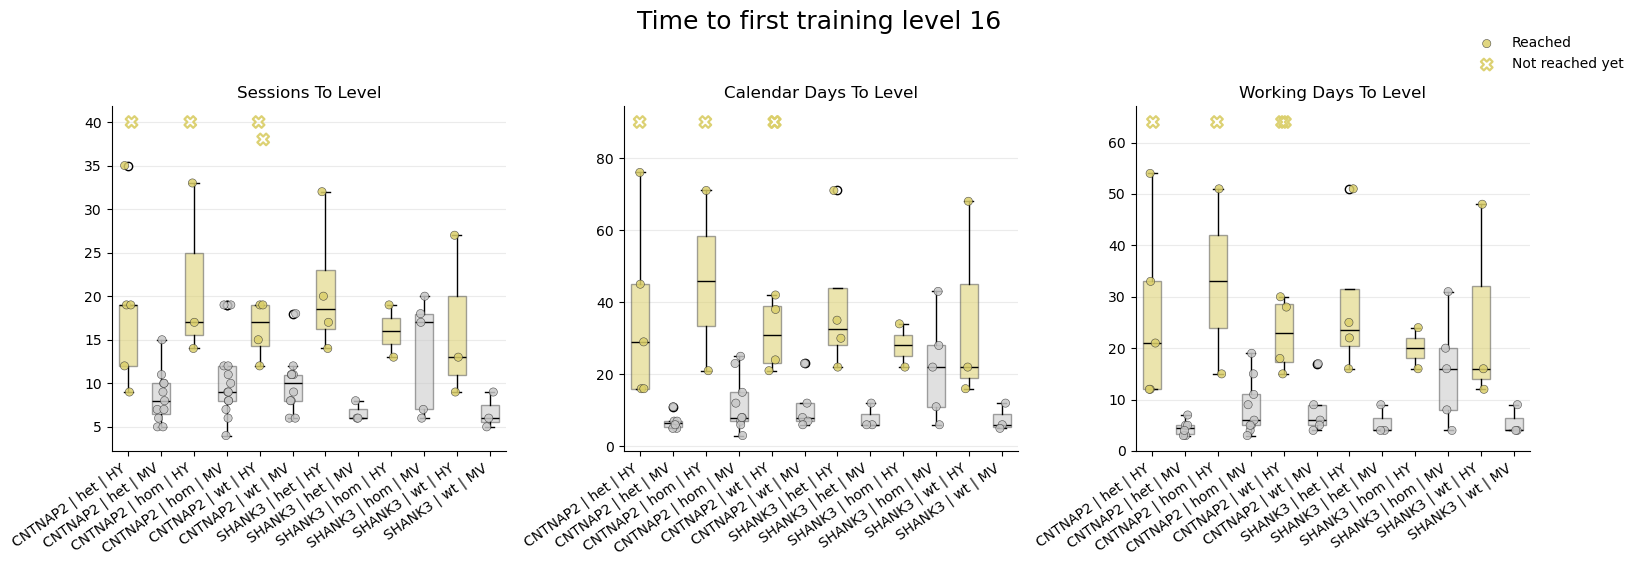

In [72]:
import numpy as np
import matplotlib.pyplot as plt

ENDPOINT_LEVEL = 16
ENDPOINT_GROUP_BY = ["line", "genotype", "experimenter"]  # e.g. ["genotype"], ["line", "genotype"], ["experimenter"]
ENDPOINT_METRICS = ["sessions_to_level", "calendar_days_to_level", "working_days_to_level"]
ENDPOINT_INCLUDE_UNREACHED = True
ENDPOINT_EXCLUDE_ANIMALS = ["ASD0013"]  # exclude animals that cannot continue, e.g. died before reaching endpoint

date_col = next((col for col in ["source_date", "session_date", "date"] if col in df_plot.columns), None)
endpoint_df = df_plot.copy()
if ENDPOINT_EXCLUDE_ANIMALS:
    excluded_animals = {str(animal).strip() for animal in ENDPOINT_EXCLUDE_ANIMALS}
    endpoint_df = endpoint_df[~endpoint_df["animal"].astype(str).str.strip().isin(excluded_animals)].copy()
    print("Excluded from endpoint summary:", sorted(excluded_animals))
endpoint_df["session_num"] = pd.to_numeric(endpoint_df["session"], errors="coerce")
endpoint_df["trial_num"] = pd.to_numeric(endpoint_df["trial"], errors="coerce")
endpoint_df["training_level_num"] = pd.to_numeric(endpoint_df["training_level"], errors="coerce")
if date_col is not None:
    endpoint_df["session_date"] = pd.to_datetime(endpoint_df[date_col], errors="coerce").dt.normalize()
else:
    endpoint_df["session_date"] = pd.NaT

endpoint_df = endpoint_df.sort_values(["animal", "session_num", "trial_num"]).copy()
meta_cols = [col for col in ["animal", "line", "cohort", "genotype", "experimenter", "dataset_key"] if col in endpoint_df.columns]
first_sessions = (
    endpoint_df.dropna(subset=["session_num"])
    .groupby("animal", dropna=False)
    .agg(
        first_session=("session_num", "min"),
        first_date=("session_date", "min"),
        max_session_observed=("session_num", "max"),
        max_date_observed=("session_date", "max"),
    )
    .reset_index()
)
animal_meta = endpoint_df[meta_cols].drop_duplicates("animal")

reached_rows = endpoint_df[endpoint_df["training_level_num"].ge(ENDPOINT_LEVEL)].copy()
first_reached = (
    reached_rows.sort_values(["animal", "session_num", "trial_num"])
    .drop_duplicates("animal")
    [["animal", "session_num", "session_date", "trial_num"]]
    .rename(columns={"session_num": "reach_session", "session_date": "reach_date", "trial_num": "reach_trial"})
)

level16_endpoints = animal_meta.merge(first_sessions, on="animal", how="left").merge(first_reached, on="animal", how="left")
level16_endpoints["reached_level"] = level16_endpoints["reach_session"].notna()
level16_endpoints["sessions_before_level"] = level16_endpoints["reach_session"] - level16_endpoints["first_session"]
level16_endpoints["sessions_to_level"] = level16_endpoints["sessions_before_level"] + 1
level16_endpoints["calendar_days_to_level"] = (level16_endpoints["reach_date"] - level16_endpoints["first_date"]).dt.days

def _working_days(row):
    if pd.isna(row["first_date"]) or pd.isna(row["reach_date"]):
        return np.nan
    return np.busday_count(row["first_date"].date(), row["reach_date"].date())

level16_endpoints["working_days_to_level"] = level16_endpoints.apply(_working_days, axis=1)
level16_endpoints["sessions_observed"] = level16_endpoints["max_session_observed"] - level16_endpoints["first_session"] + 1
level16_endpoints["calendar_days_observed"] = (level16_endpoints["max_date_observed"] - level16_endpoints["first_date"]).dt.days

def _working_days_observed(row):
    if pd.isna(row["first_date"]) or pd.isna(row["max_date_observed"]):
        return np.nan
    return np.busday_count(row["first_date"].date(), row["max_date_observed"].date())

level16_endpoints["working_days_observed"] = level16_endpoints.apply(_working_days_observed, axis=1)
level16_endpoints = level16_endpoints.sort_values([col for col in ENDPOINT_GROUP_BY if col in level16_endpoints.columns] + ["animal"])

display_cols = [
    col for col in [
        "animal", "line", "cohort", "genotype", "experimenter", "dataset_key", "reached_level",
        "first_session", "reach_session", "sessions_to_level", "first_date", "reach_date",
        "calendar_days_to_level", "working_days_to_level", "max_session_observed", "max_date_observed",
        "sessions_observed", "calendar_days_observed", "working_days_observed",
    ] if col in level16_endpoints.columns
]
display(level16_endpoints[display_cols])

summary_source = level16_endpoints if ENDPOINT_INCLUDE_UNREACHED else level16_endpoints[level16_endpoints["reached_level"]]
group_cols = [col for col in ENDPOINT_GROUP_BY if col in summary_source.columns]
level16_summary = (
    summary_source.groupby(group_cols, dropna=False)
    .agg(
        animals=("animal", "nunique"),
        reached=("reached_level", "sum"),
        median_sessions_to_level=("sessions_to_level", "median"),
        mean_sessions_to_level=("sessions_to_level", "mean"),
        median_calendar_days=("calendar_days_to_level", "median"),
        median_working_days=("working_days_to_level", "median"),
    )
    .reset_index()
)
level16_summary["not_reached"] = level16_summary["animals"] - level16_summary["reached"]
display(level16_summary)

plot_df = level16_endpoints.copy() if ENDPOINT_INCLUDE_UNREACHED else level16_endpoints[level16_endpoints["reached_level"]].copy()
if plot_df.empty:
    print("No animals available after the current filters.")
else:
    plot_df["endpoint_group"] = plot_df[group_cols].astype(str).agg(" | ".join, axis=1) if group_cols else "all animals"
    groups = sorted(plot_df["endpoint_group"].dropna().unique())
    metric_observed = {
        "sessions_to_level": "sessions_observed",
        "calendar_days_to_level": "calendar_days_observed",
        "working_days_to_level": "working_days_observed",
    }
    fig, axes = plt.subplots(1, len(ENDPOINT_METRICS), figsize=(5.5 * len(ENDPOINT_METRICS), 5.5), sharex=False)
    if len(ENDPOINT_METRICS) == 1:
        axes = [axes]
    rng = np.random.default_rng(0)
    group_colors = []
    for group in groups:
        group_sub = plot_df[plot_df["endpoint_group"] == group]
        experimenters = sorted(group_sub["experimenter"].dropna().astype(str).str.strip().unique()) if "experimenter" in group_sub else []
        group_colors.append(EXPERIMENTER_COLOR_OVERRIDES.get(experimenters[0], "#D8DEE9") if len(experimenters) == 1 else "#D8DEE9")
    for ax, metric in zip(axes, ENDPOINT_METRICS):
        reached_data = [
            pd.to_numeric(plot_df.loc[(plot_df["endpoint_group"] == group) & plot_df["reached_level"], metric], errors="coerce").dropna().to_numpy()
            for group in groups
        ]
        box = ax.boxplot(reached_data, positions=np.arange(len(groups)), widths=0.55, patch_artist=True, boxprops=dict(edgecolor="0.35"), medianprops=dict(color="black"))
        for patch, color in zip(box["boxes"], group_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.55)
        for idx, group in enumerate(groups):
            group_sub = plot_df[plot_df["endpoint_group"] == group].copy()
            reached_sub = group_sub[group_sub["reached_level"]].copy()
            unreached_sub = group_sub[~group_sub["reached_level"]].copy()
            if not reached_sub.empty:
                y = pd.to_numeric(reached_sub[metric], errors="coerce").dropna()
                if len(y):
                    jitter = rng.uniform(-0.12, 0.12, size=len(y))
                    colors = [EXPERIMENTER_COLOR_OVERRIDES.get(str(exp).strip(), group_colors[idx]) for exp in reached_sub.loc[y.index, "experimenter"]]
                    ax.scatter(np.full(len(y), idx) + jitter, y, s=35, color=colors, edgecolor="0.20", linewidth=0.4, alpha=0.85, zorder=3, label="Reached" if idx == 0 else None)
            observed_metric = metric_observed.get(metric)
            if ENDPOINT_INCLUDE_UNREACHED and observed_metric and not unreached_sub.empty:
                y = pd.to_numeric(unreached_sub[observed_metric], errors="coerce").dropna()
                if len(y):
                    jitter = rng.uniform(-0.12, 0.12, size=len(y))
                    colors = [EXPERIMENTER_COLOR_OVERRIDES.get(str(exp).strip(), group_colors[idx]) for exp in unreached_sub.loc[y.index, "experimenter"]]
                    ax.scatter(np.full(len(y), idx) + jitter, y, s=70, marker="X", facecolors="none", edgecolors=colors, linewidth=1.6, alpha=0.95, zorder=4, label="Not reached yet" if idx == 0 else None)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xticks(np.arange(len(groups)))
        ax.set_xticklabels(groups, rotation=35, ha="right")
        ax.grid(axis="y", alpha=0.25)
        for spine in ["right", "top"]:
            ax.spines[spine].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.995, 0.995), frameon=False)
    fig.suptitle(f"Time to first training level {ENDPOINT_LEVEL}", fontsize=18, y=1.02)
    fig.tight_layout(rect=[0, 0, 0.94, 0.98])
    plt.show()


## 7. Plot From Prepared Data

Change `PLOT_MODE` and rerun this cell without recomputing preparation.

- `training_level_colormap`: one panel per selected view; one colorbar for training level
- `time_in_level_scatter`: per-animal time in level with jittered points
- `time_in_level_boxplot`: grouped boxplots by training level
- `all`: make all figure families

In [ ]:
import importlib
import matplotlib.pyplot as plt
lc = importlib.reload(lc)
plt.close("all")

PLOT_MODE = "time_in_level_boxplot"
PLOT_VIEW = None      # backward-compatible single-view selector
PLOT_VIEWS = None     # plot only these view names, e.g. ["HY wt/het/hom", "MV wt/het/hom"]
HIDE_VIEWS = []       # hide these view names without rebuilding, e.g. ["ATM wt/het/hom"]
SPLIT_FIGURES_BY = ["strain", "genotype"]  # None, "genotype", "line"/"strain", or a list like ["strain", "genotype"]
ANNOTATE_MEDIAN_SPLIT = False  # for boxplots: show counts above/below each median as A#/B#
SHOW_ANIMAL_N_BOX = True  # add a plot-level text box with n animals per view/experimenter
TIME_UNIT = "hour"   # "sec", "min", or "hour"

if PLOT_VIEW is not None and PLOT_VIEWS is not None:
    raise ValueError("Use either PLOT_VIEW or PLOT_VIEWS, not both.")

selected_plot_views = {PLOT_VIEW} if PLOT_VIEW is not None else None
if PLOT_VIEWS is not None:
    selected_plot_views = {str(view).strip() for view in PLOT_VIEWS}
hidden_plot_views = {str(view).strip() for view in HIDE_VIEWS}

plot_views = [
    v for v in views
    if (selected_plot_views is None or v.name in selected_plot_views) and v.name not in hidden_plot_views
]
if not plot_views:
    available = [v.name for v in views]
    raise ValueError(f"No views selected. Available views: {available}")

print("Plotting views:", [v.name for v in plot_views])

def add_animal_n_box(fig, plot_bundle, selected_views):
    if not SHOW_ANIMAL_N_BOX or fig is None:
        return
    lines = ["Animals"]
    for view in selected_views:
        sub = view.selector(plot_bundle["df"])
        label = plot_bundle["view_labels"].get(view.name, view.name)
        n_animals = sub["animal"].dropna().astype(str).str.strip().nunique() if "animal" in sub else 0
        lines.append(f"{label}: n={n_animals}")
    fig.text(
        0.985,
        0.985,
        "\n".join(lines),
        ha="right",
        va="top",
        fontsize=max(8, plot_bundle["style"].legend_fs - 3),
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.9),
    )

split_aliases = {None: None, "none": None, "genotype": "genotype", "genotypes": "genotype", "line": "line", "lines": "line", "strain": "line", "strains": "line"}
if SPLIT_FIGURES_BY is None or SPLIT_FIGURES_BY == "none":
    split_cols = []
elif isinstance(SPLIT_FIGURES_BY, (list, tuple, set)):
    split_cols = [split_aliases.get(str(split).strip().lower()) for split in SPLIT_FIGURES_BY]
else:
    split_cols = [split_aliases.get(str(SPLIT_FIGURES_BY).strip().lower())]
if any(split_col is None for split_col in split_cols):
    raise ValueError('SPLIT_FIGURES_BY must be None, "genotype", "line"/"strain", or a list of those.')
split_cols = list(dict.fromkeys(split_cols))

if not split_cols:
    out = lc.plot_learning_curve_figures(
        bundle=bundle,
        views=plot_views,
        plot_mode=PLOT_MODE,
        time_unit=TIME_UNIT,
        show=False,
        annotate_median_split=ANNOTATE_MEDIAN_SPLIT,
    )
    for fig in out["figures"].values():
        if fig is not None:
            add_animal_n_box(fig, bundle, plot_views)
            fig.tight_layout(rect=[0, 0, 0.86 if SHOW_ANIMAL_N_BOX else 1, 0.98])
            plt.figure(fig.number)
            plt.show()
            plt.close(fig)
else:
    split_rows = (
        bundle["df"][split_cols]
        .dropna()
        .astype(str)
        .apply(lambda col: col.str.strip())
        .drop_duplicates()
        .sort_values(split_cols)
    )
    out = {"figures": {}}
    for _, split_row in split_rows.iterrows():
        split_values = split_row.to_dict()
        split_title_parts = []
        for col, value in split_values.items():
            title_name = "Strain/line" if col == "line" else col.replace("_", " ").title()
            title_value = value.upper() if col == "genotype" else value
            split_title_parts.append(f"{title_name}: {title_value}")
        split_label = " | ".join(split_title_parts)
        split_key = "__".join(f"{col}_{value}" for col, value in split_values.items())
        split_views = []
        split_labels = {}
        split_colors = {}
        for view in plot_views:
            def _selector(d, _view=view, _split_values=split_values):
                sub = _view.selector(d)
                mask = pd.Series(True, index=sub.index)
                for _split_col, _split_value in _split_values.items():
                    mask &= sub[_split_col].astype(str).str.strip().eq(_split_value)
                return sub[mask].copy()

            test_sub = _selector(bundle["df"])
            if test_sub.empty:
                continue
            split_view = ViewSpec(view.name, _selector)
            split_views.append(split_view)
            base_label = bundle["view_labels"].get(view.name, view.name)
            if str(COMPARISON).strip().lower() in {"experimenter", "experimentor"}:
                base_label = str(view.name).split(" ", 1)[0]
            split_labels[split_view.name] = base_label
            split_colors[split_view.name] = bundle["view_colors"].get(view.name, "0.5")

        if not split_views:
            continue

        split_bundle = lc.prepare_learning_curve_bundle(
            df=bundle["df"],
            views=split_views,
            span=bundle["span"],
            normalized_points=bundle["normalized_points"],
            drop_repeat_trials=False,
            valid_success_values=VALID_SUCCESS_VALUES,
            time_col=bundle["time_col"],
            level_max_exclusive=bundle["level_max_exclusive"],
            style=bundle["style"],
            view_labels=split_labels,
            view_colors=split_colors,
        )
        print(f"Plotting {split_label}:", [v.name for v in split_views])
        split_out = lc.plot_learning_curve_figures(
            bundle=split_bundle,
            views=split_views,
            plot_mode=PLOT_MODE,
            time_unit=TIME_UNIT,
            show=False,
            annotate_median_split=ANNOTATE_MEDIAN_SPLIT,
        )
        for fig in split_out["figures"].values():
            if fig is not None:
                fig.suptitle(split_label, y=1.02, fontsize=bundle["style"].title_fs)
                add_animal_n_box(fig, split_bundle, split_views)
                fig.tight_layout(rect=[0, 0, 0.86 if SHOW_ANIMAL_N_BOX else 1, 0.95])
                plt.figure(fig.number)
                plt.show()
                plt.close(fig)
        out["figures"][split_key] = split_out["figures"]

print("Figure keys:", list(out["figures"].keys()))

Plotting views: ['HY wt/het/hom', 'MV wt/het/hom']


## 8. Example Recipes

### Compare genotypes within one cohort

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
GENOTYPES = ["wt", "het", "hom"]
```

### One learning-curve figure per animal

```python
COMPARISON = "animals"
PLOT_MODE = "training_level_colormap"
```

### Compare only the hom group across datasets

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
COMPARISON = "datasets"
GENOTYPES = ["hom"]
```

### Time in level as boxplots

```python
PLOT_MODE = "time_in_level_boxplot"
TIME_UNIT = "hour"
FIRST_N_SESSIONS = None
STOP_AT_TRAINING_LEVEL = 16
```

### Toggle experimenters

```python
COMPARISON = "experimenter"
EXPERIMENTER_SELECTION = ["HY", "MV"]  # rebuild data/views with only these experimenters

# Or, after preparing the bundle, hide/show views just for plotting:
PLOT_VIEWS = ["HY wt/het/hom", "MV wt/het/hom"]
HIDE_VIEWS = ["ATM wt/het/hom"]
```

### One figure per genotype or strain

```python
# Keeps the selected views inside each figure, e.g. experimenters within each genotype.
SPLIT_FIGURES_BY = "genotype"

# Or split by strain/line:
SPLIT_FIGURES_BY = "strain"  # same as "line"

# Experimenter traces, separated into one figure per strain x genotype:
COMPARISON = "experimenter"
SPLIT_FIGURES_BY = ["strain", "genotype"]
```